# VM Allocation Optimization Benchmark

### BENCHMARK PURPOSE :

The purpose of this benchmark is to generate large-scale synthetic datasets in order to evaluate and compare the computational performance of different VM allocation solvers. Specifically, we aim to measure and analyze the execution time, scalability, and solution quality of three approaches: First Fit Decreasing (FFD), Mixed Integer Linear Programming (PLNE/MILP), and CP-SAT constraint programming. By applying these solvers to identical problem instances of increasing size and complexity, we can assess their efficiency under realistic constraints such as capacity limits, affinity/anti-affinity rules, and resource fragmentation. The goal is to identify the trade-offs between speed and optimality, and to determine which solver provides the best balance for large-scale infrastructure allocation problems.

In [11]:
# imports

import random
from time import perf_counter, process_time
from typing import Any, Callable, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from vm_allocation.datasets.generate_dataset import (
    generate_n_servers,
    generate_n_vms_with_context,
)
from vm_allocation.models import VM, Context, Solver
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

In [12]:
BENCHMARK_SEED = 42

random.seed(BENCHMARK_SEED)

## Problem initialization

In [13]:
# we create a context with 15 servers and 80 VMs, then we plot the context
all_servers = generate_n_servers(15)
context = Context(all_servers)

vms, random_context = generate_n_vms_with_context(80, context)

# we print affinity and anti-affinity rules

# VISUAL FOR RANDOM CONTEXT

VMs number: 80


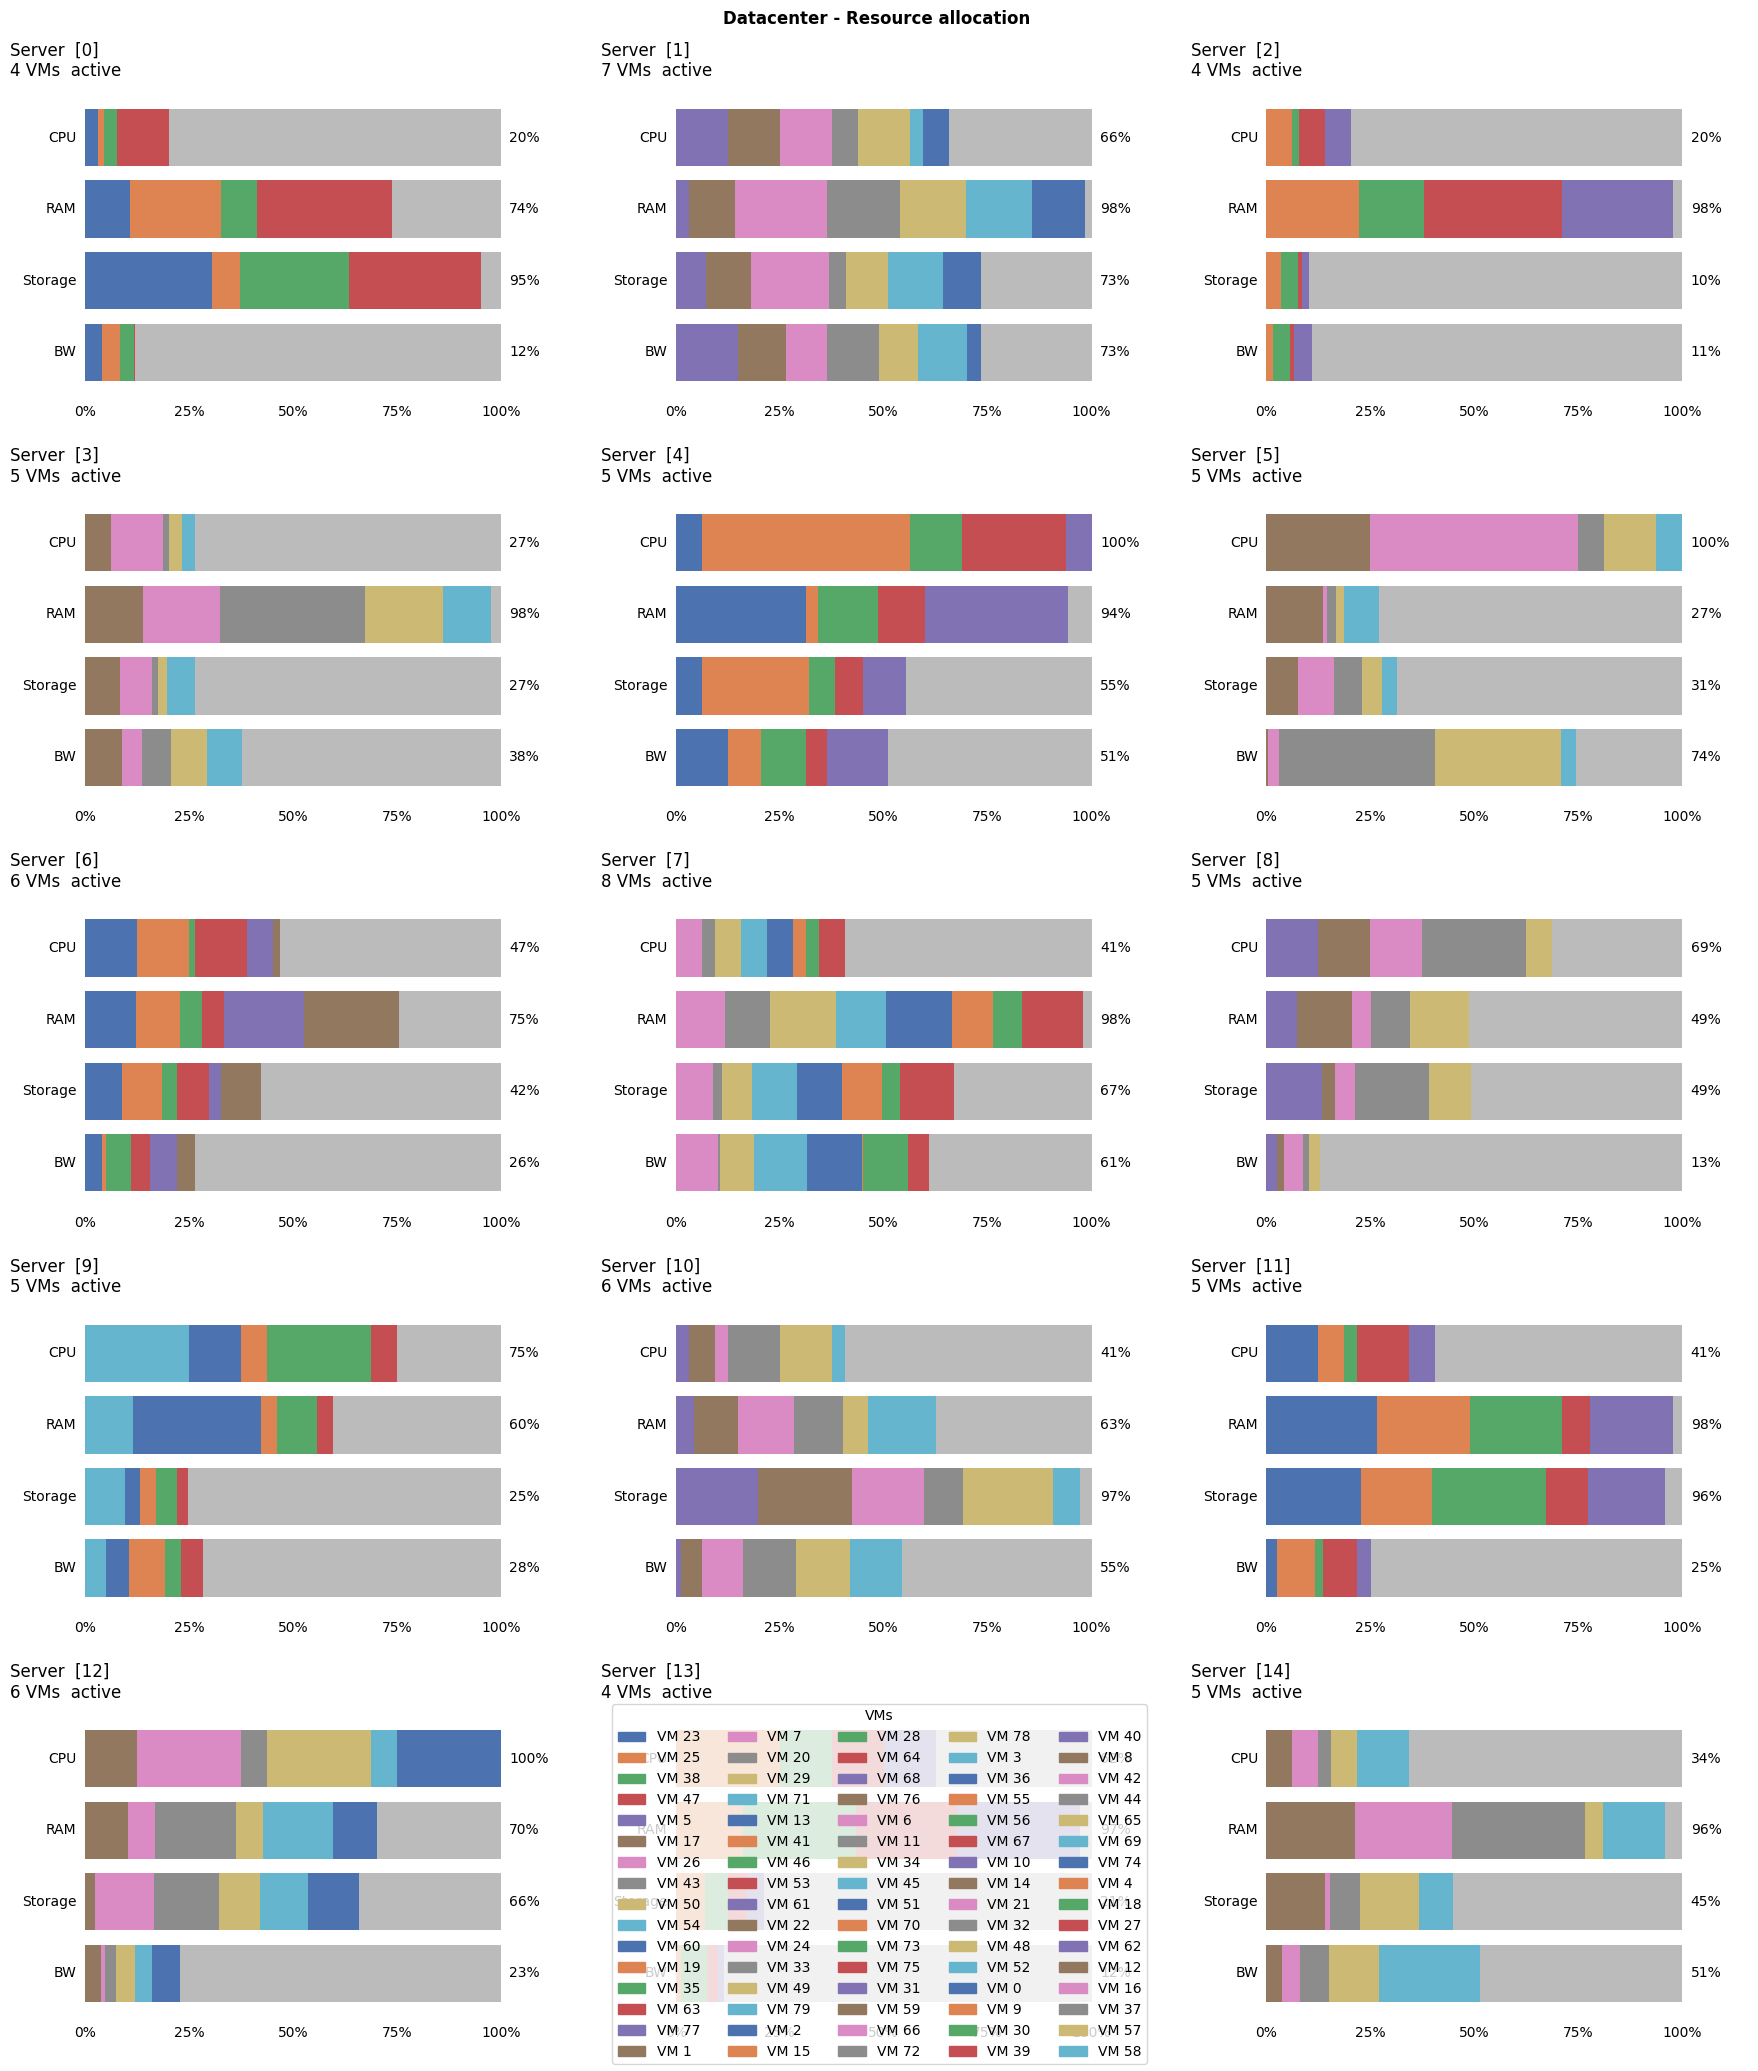

In [14]:
print("VMs number:", len(vms))

fig = random_context.plot()
fig

# Solver initialization and dataset duplication

In [15]:
# FDD
fdd = FFDSolver()
context_for_FDD = context.copy()
new_vms_for_FDD = [vm.copy() for vm in vms]

# PLNE
plne = PLNESolver()
context_for_PLNE = context.copy()
new_vms_for_PLNE = [vm.copy() for vm in vms]

# CPSAT
cpsat = CPSATSolver(server_usage_weight=1000, max_time_in_seconds=30)
context_for_CPSAT = context.copy()
new_vms_for_CPSAT = [vm.copy() for vm in vms]


# SPEED TEST

In [16]:
# FDD
start = perf_counter()
solution_context_fdd = fdd.solve(new_vms_for_FDD, context_for_FDD)
end = perf_counter()
fdd_time = end - start

# PLNE
start = perf_counter()
solution_context_plne = plne.solve(new_vms_for_PLNE, context_for_PLNE)
end = perf_counter()
plne_time = end - start

# CPSAT
start = perf_counter()
solution_context_cpsat = cpsat.solve(new_vms_for_CPSAT, context_for_CPSAT)
end = perf_counter()
cpsat_time = end - start

# print the results
print(
    f"FDD time: {fdd_time:.4f} seconds ({'successful' if solution_context_fdd is not None else 'failed'})"
)
print(
    f"PLNE time: {plne_time:.4f} seconds ({'successful' if solution_context_plne is not None else 'failed'})"
)
print(
    f"CPSAT time: {cpsat_time:.4f} seconds ({'successful' if solution_context_cpsat is not None else 'failed'})"
)


FDD time: 0.0015 seconds (successful)
PLNE time: 4.7913 seconds (successful)
CPSAT time: 30.0471 seconds (successful)


# Visuals for context solutions

## FDD

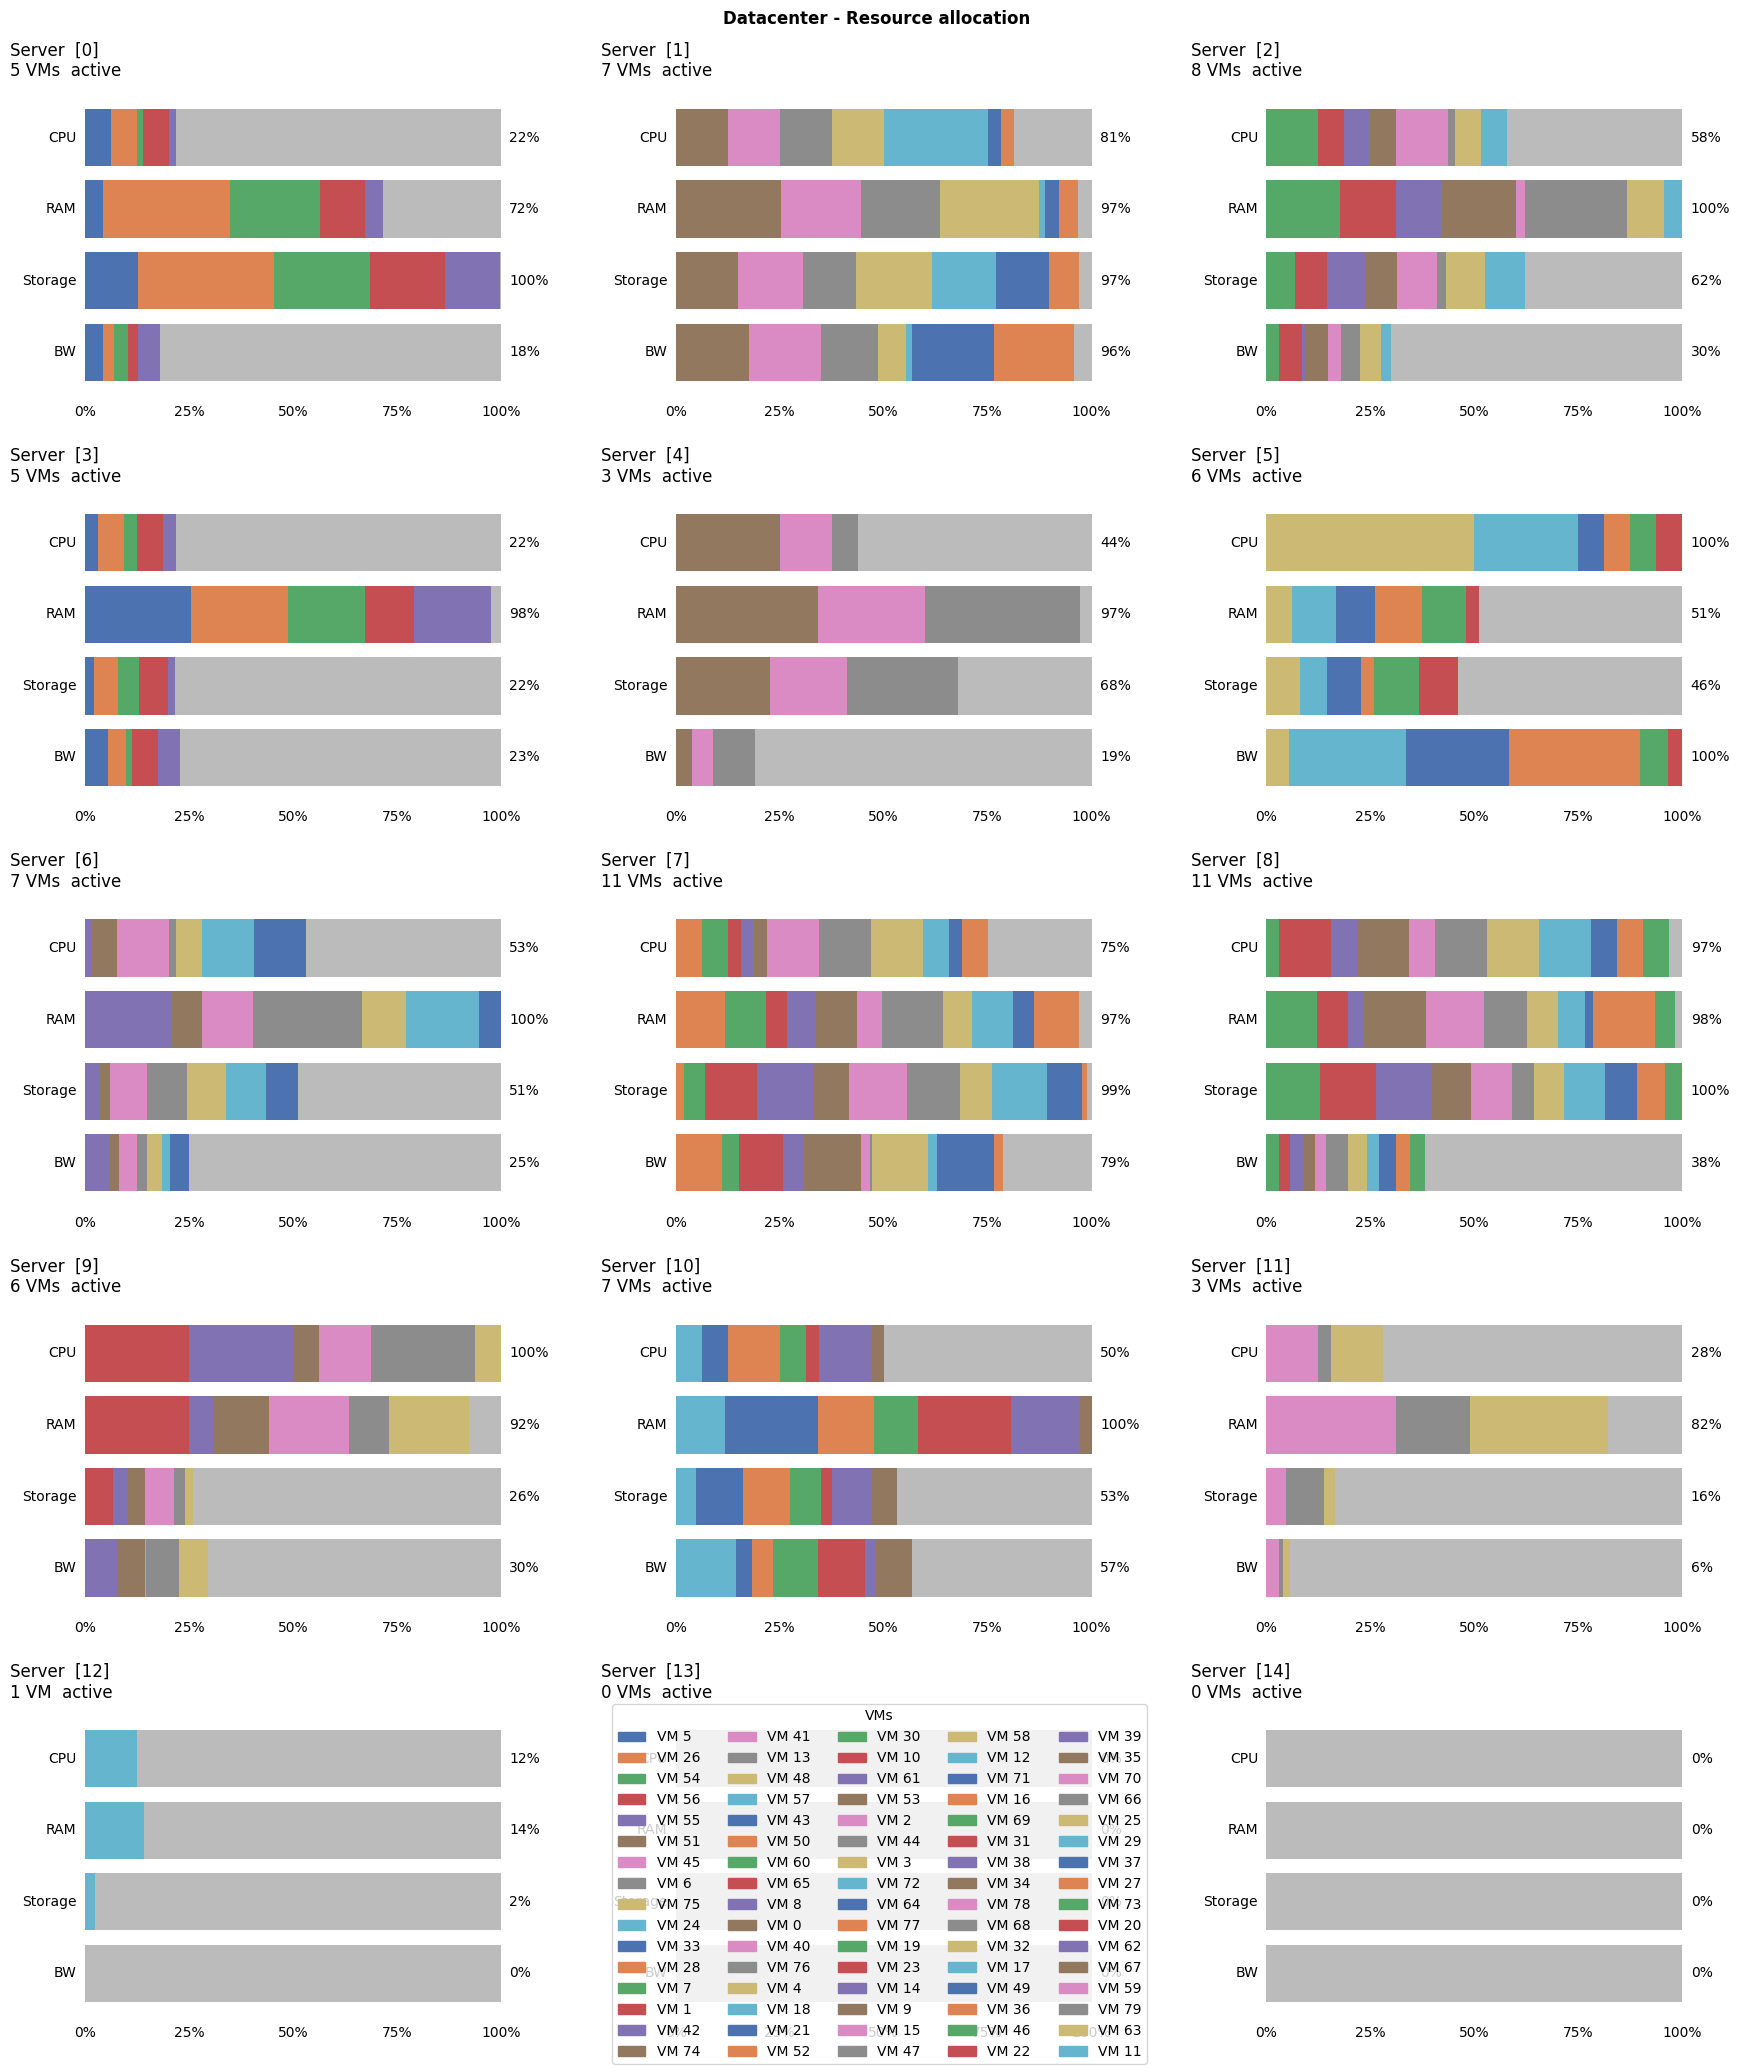

In [17]:
fig = solution_context_fdd.plot() if solution_context_fdd else None
fig


## CP-SAT

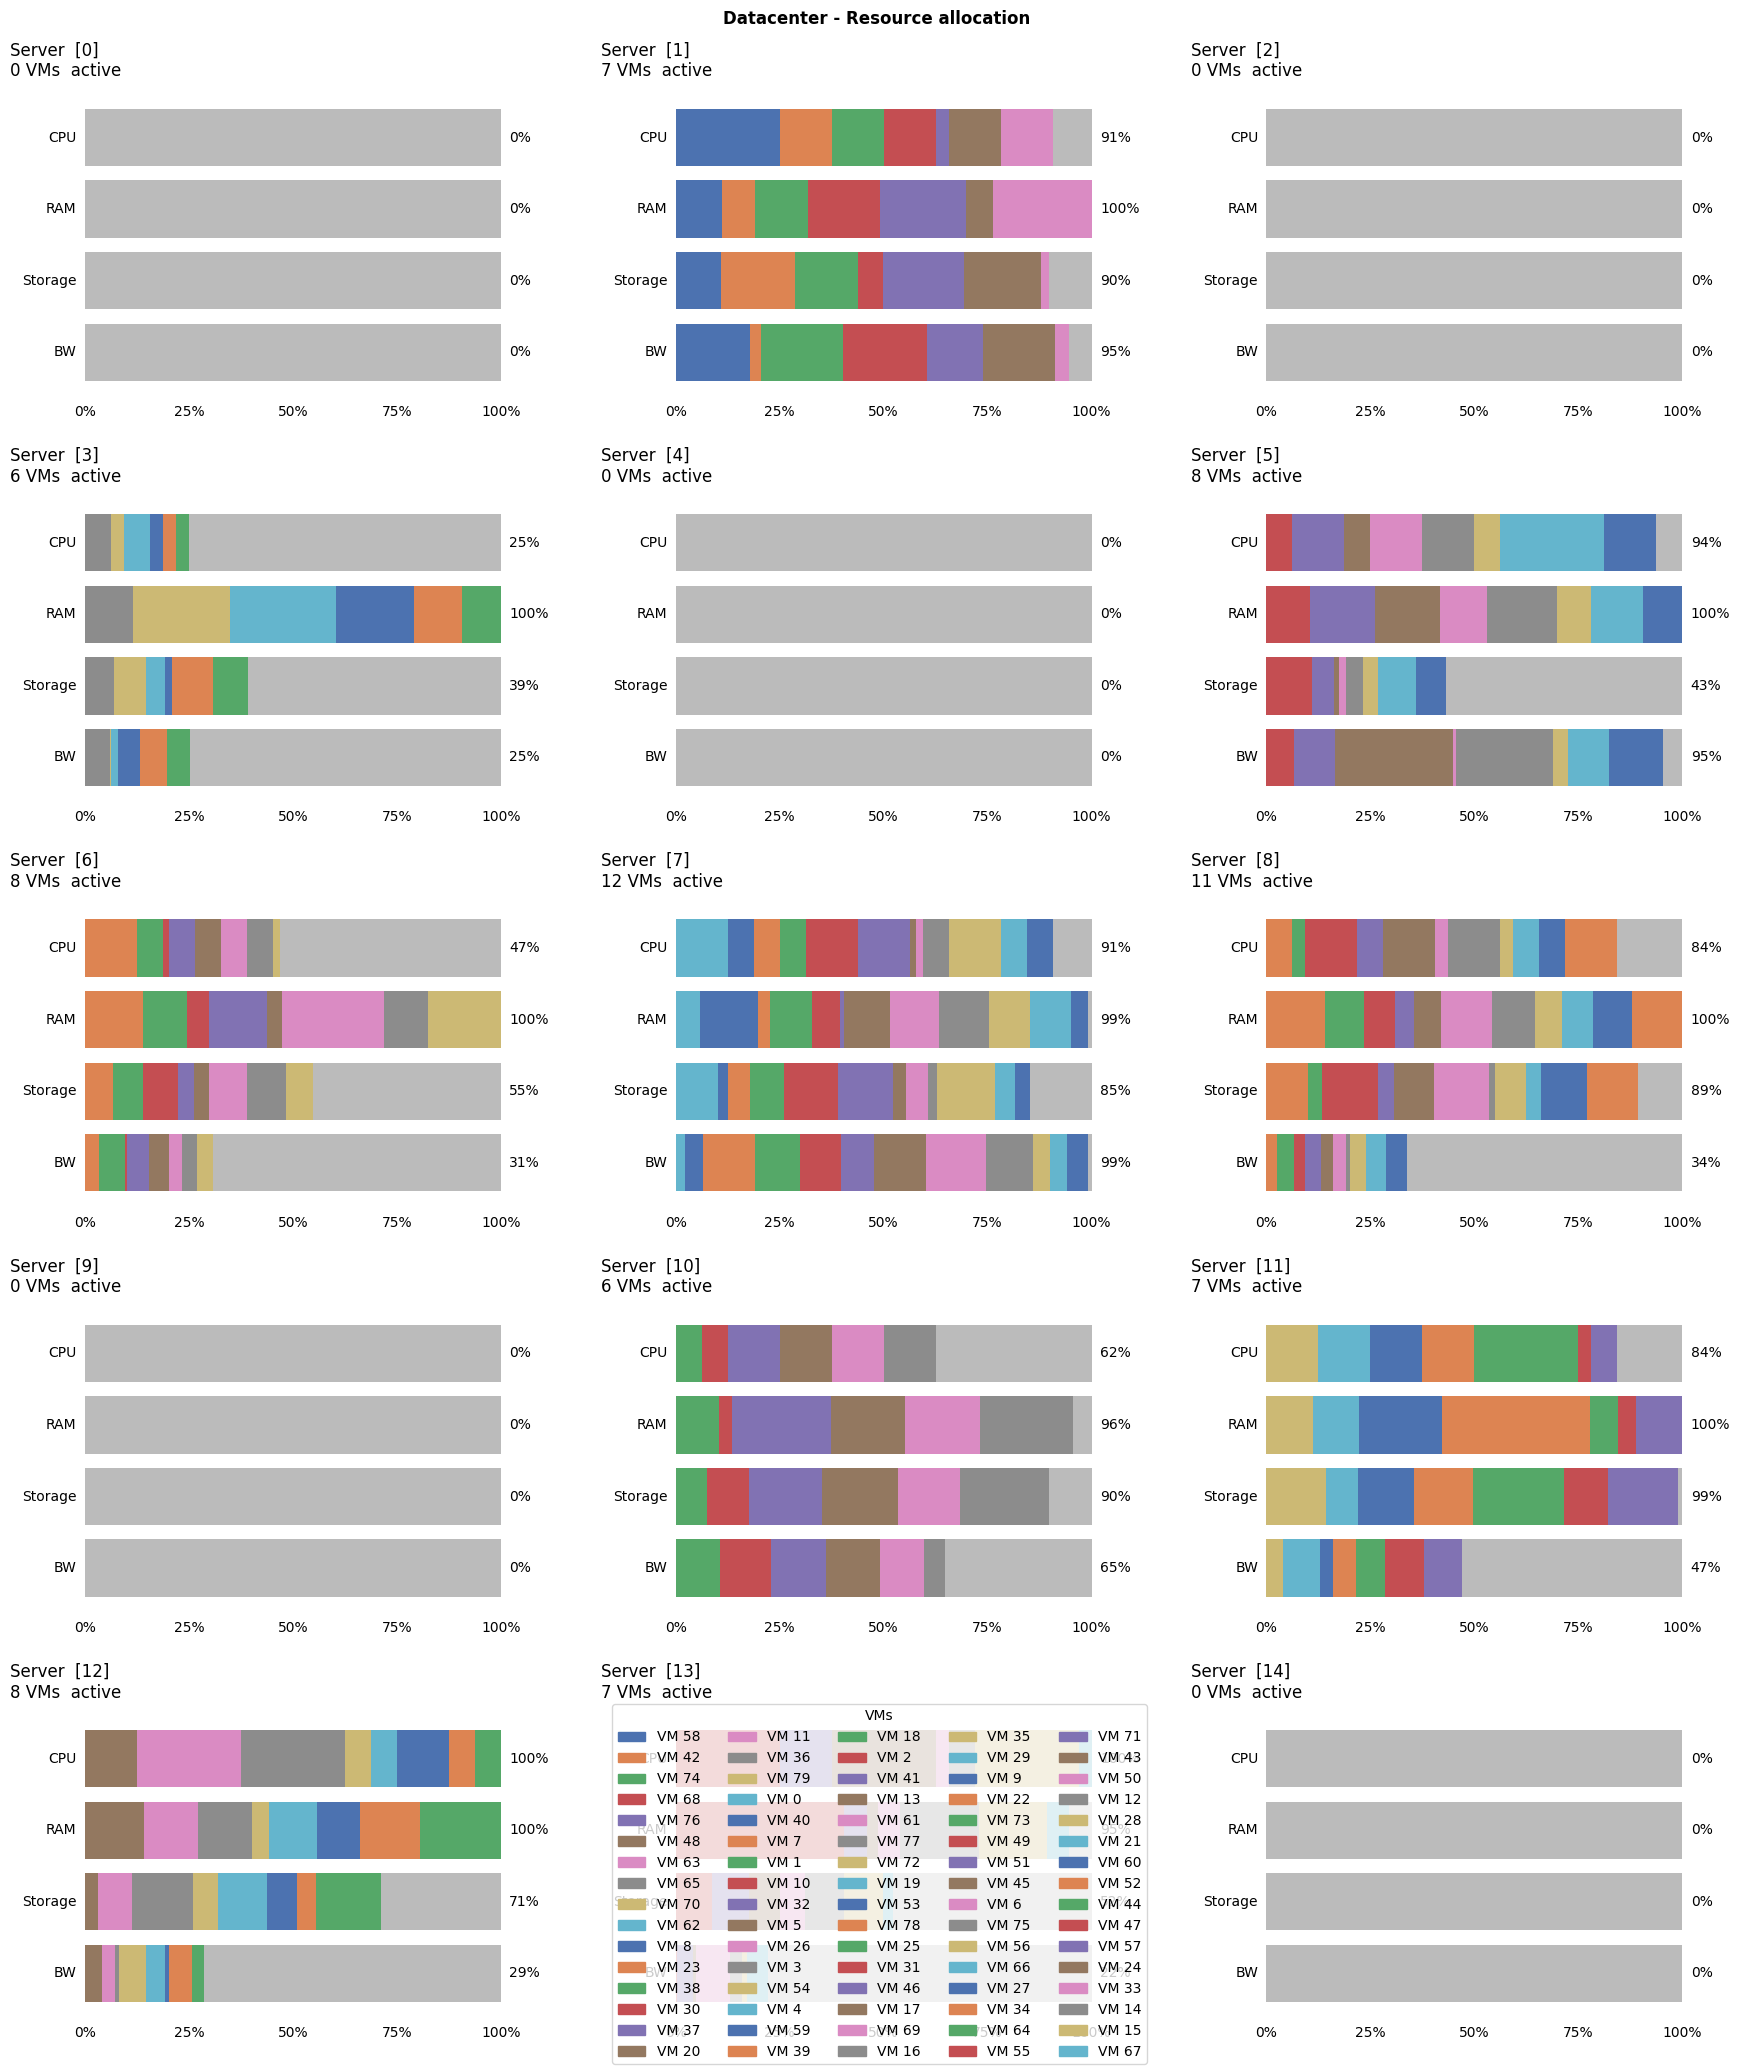

In [18]:
fig = solution_context_cpsat.plot() if solution_context_cpsat else None
fig


## PLNE

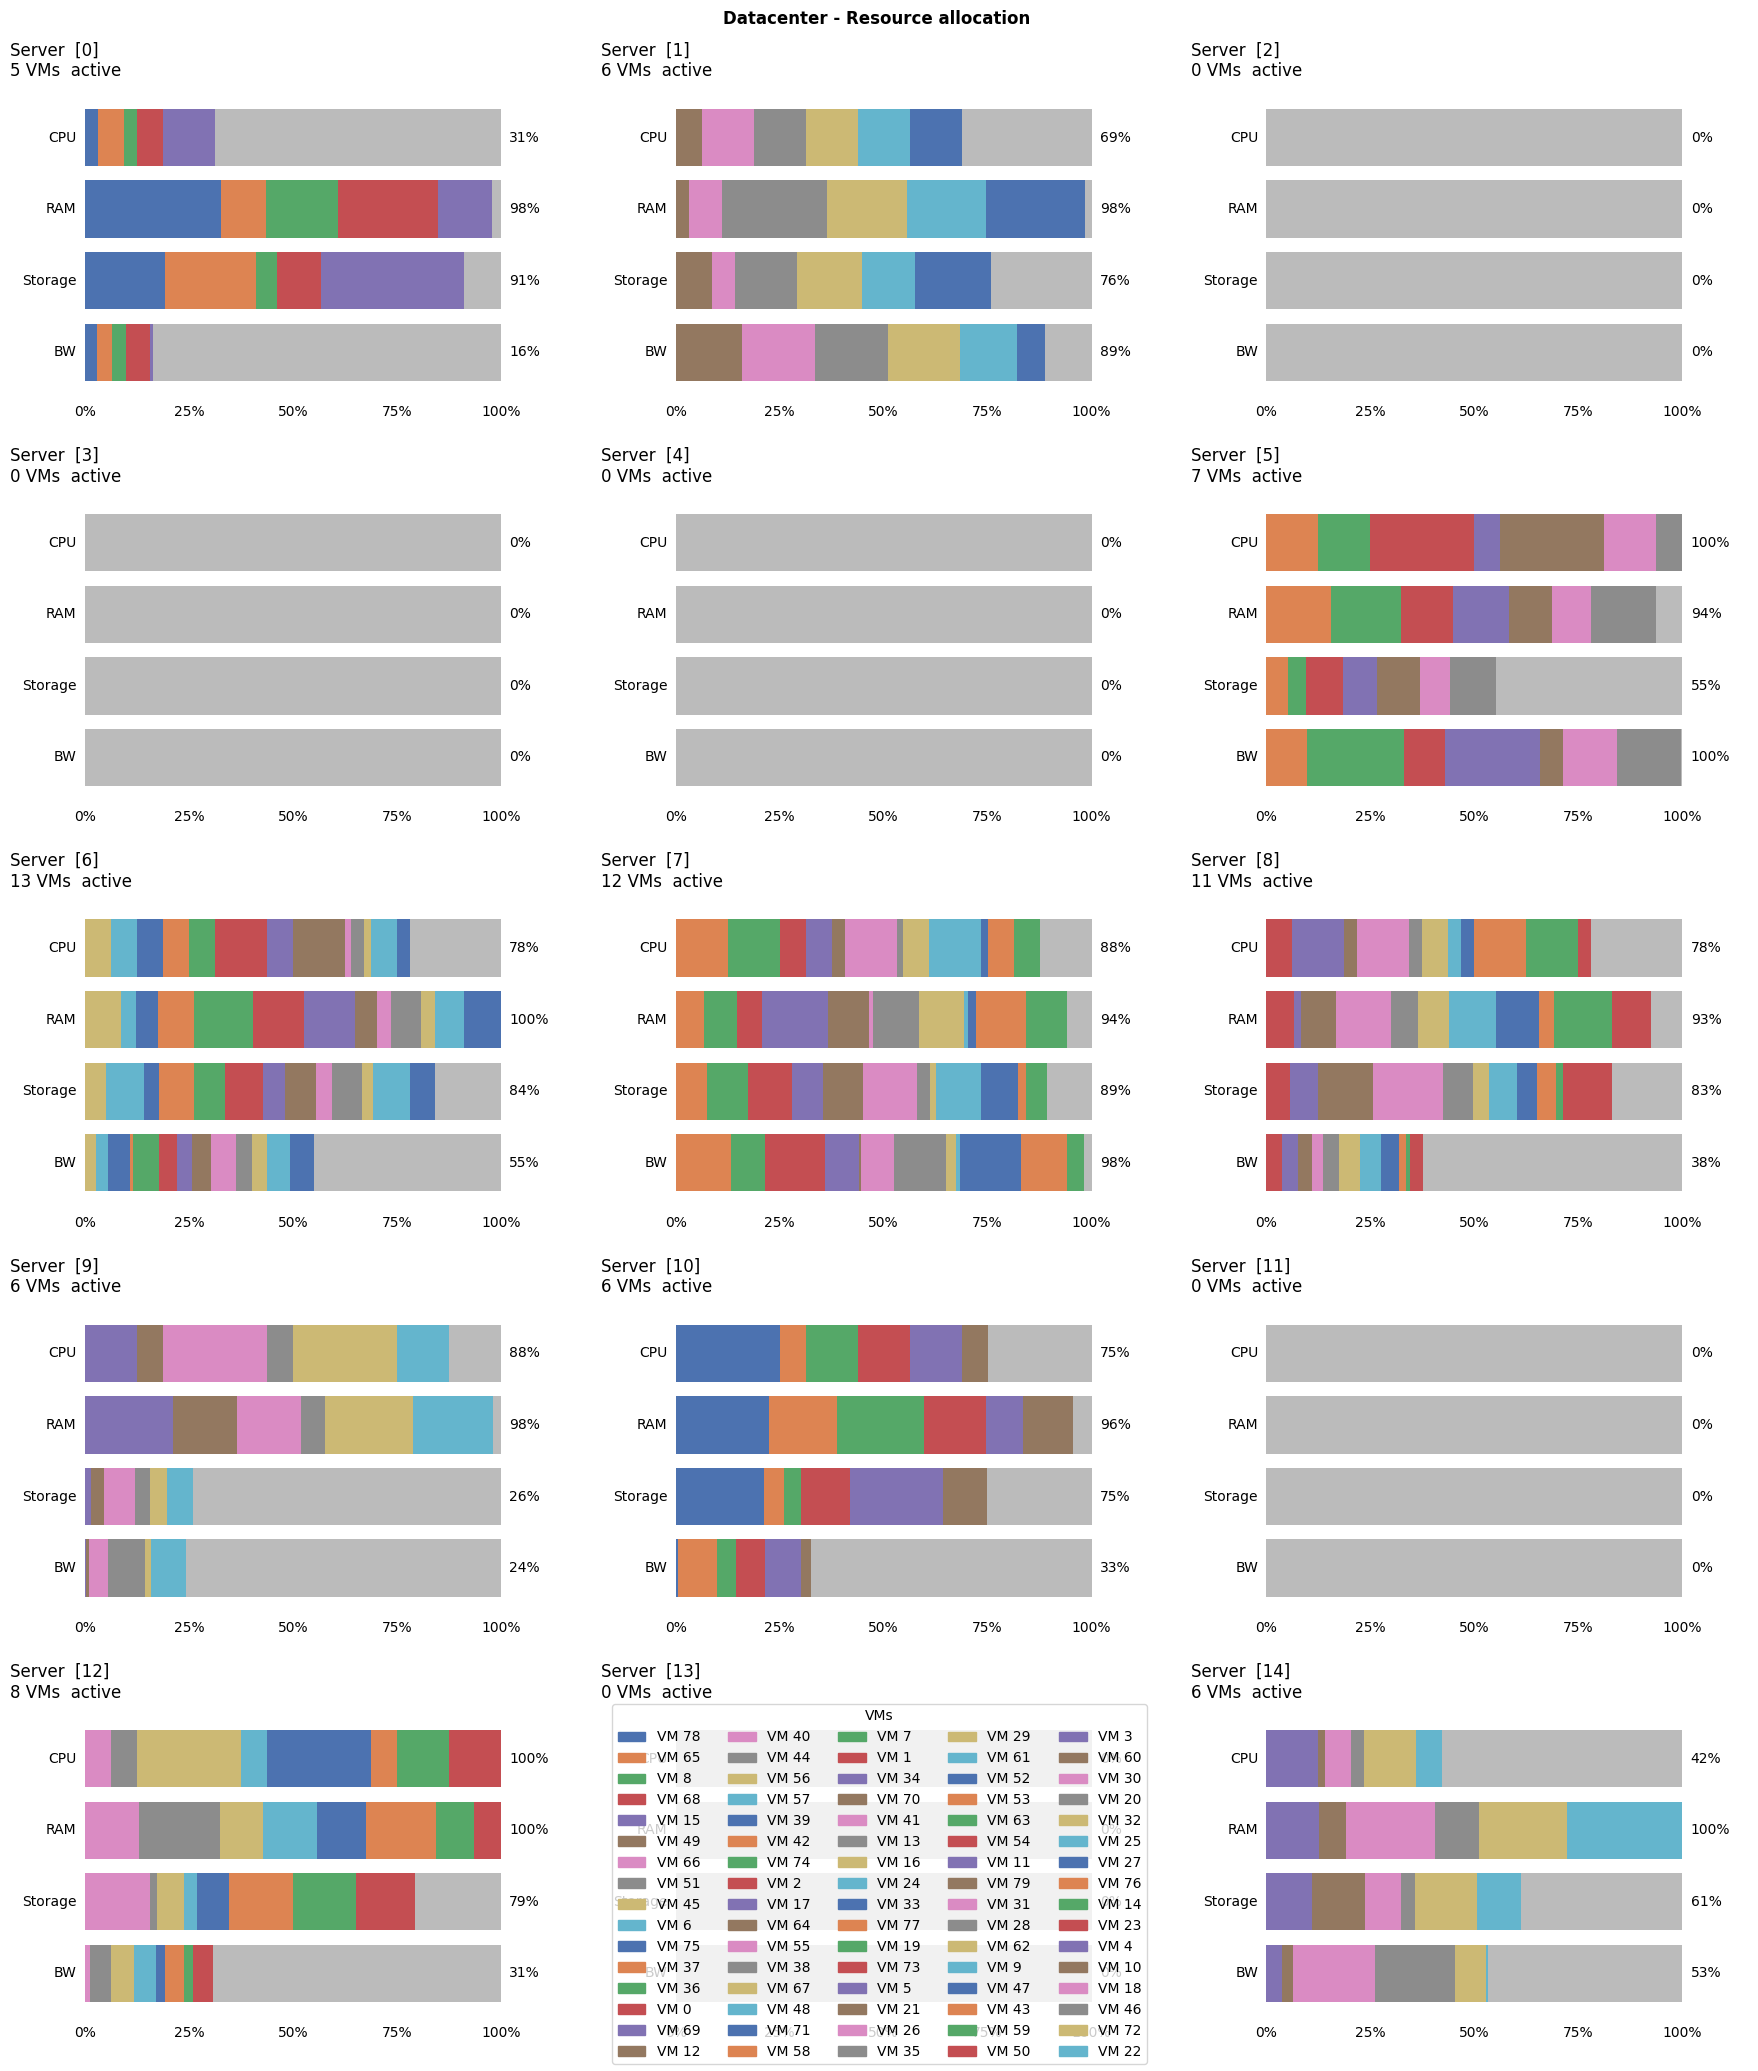

In [19]:
fig = solution_context_plne.plot() if solution_context_plne else None
fig


# SPEED AND SCALABILITY TEST

In [20]:
# Global variables
SOLVER_FACTORIES = {
    "FFD": lambda: FFDSolver(),
    "CP-SAT": lambda: CPSATSolver(max_time_in_seconds=30),
    "PLNE": lambda: PLNESolver(),
}

# Increase the instance size by 10 VMs at each step.
# N_RUNS controls how many random instances are averaged for each size.
VM_COUNTS = list(range(10, 81, 10))
N_RUNS = 5
SERVER_COUNT = 8
VERBOSE_BENCHMARK = False

In [21]:
def copy_vms(vms: list[VM]) -> list[VM]:
    """Create a list of VM copies from a list of VMs.

    Parameters
    ----------
    vms : list[VM]
        The original list of VMs.

    Returns
    -------
    list[VM]
        The list of copies.
    """
    return [vm.copy() for vm in vms]


def measure_solver(
    solver_factory: Callable[[], Solver],
    benchmark_vms: list[VM],
    benchmark_context: Context,
) -> tuple[Context | None, float, float]:
    """Perform a benchmark on a solver.

    Parameters
    ----------
    solver_factory : Callable[[], Solver]
        Function returning a solver.
    benchmark_vms : list[VM]
        List of VMs to solve with.
    benchmark_context : Context
        Context to solve with.

    Returns
    -------
    tuple[Context | None, float, float]
        A tuple of the returned solution, the wall time elapsed and the process
        time elapsed.
    """
    solver = solver_factory()
    start_time = perf_counter()
    start_process_time = process_time()
    solution = solver.solve(copy_vms(benchmark_vms), benchmark_context.copy())
    elapsed_time = perf_counter() - start_time
    elapsed_process_time = process_time() - start_process_time
    return solution, elapsed_time, elapsed_process_time


def run_scalability_benchmark(
    solver_factories: Mapping[str, Callable[[], Solver]],
    vm_counts: list[int],
    nb_benchmark: int,
    nb_server: int = 8,
    affinity_chance: float = 0.0,
    anti_affinity_server_selection_chance: float = 0.0,
    anti_affinity_chance: float = 0.0,
    verbose: bool = False,
) -> pd.DataFrame:
    """Runs scalability benchmark using the given solver factories and counts.

    Parameters
    ----------
    solver_factories : Mapping[str, Callable[[], Solver]]
        A mapping to functions to create solvers.
    vm_counts : list[int]
        The list of all VM counts to benchmark.
    nb_test : int
        The number of benchmark to perform for a VM count per solver.
    nb_server : int, optional
        The number of servers, by default 8
    affinity_chance : float, optional
        The chance to generate an affinity between VMs, by default 0.0.
    anti_affinity_server_selection_chance : float, optional
        The chance to select a server for anti-affinity generation, by default 0.0.
    anti_affinity_chance : float, optional
        The chance to generate an anti-affinity between VMs, by default 0.0.
    verbose : bool, optional
        Should the benchmark print debug outputs, by default False.

    Returns
    -------
    pd.DataFrame
        A dataframe containing the results.
    """
    records: list[dict[str, Any]] = []
    total_solver_runs = len(vm_counts) * nb_benchmark * len(solver_factories)
    completed_solver_runs = 0
    benchmark_start = perf_counter()

    if verbose:
        print(
            f"Starting benchmark: {len(vm_counts)} VM sizes, "
            f"{nb_benchmark} runs per size, {len(solver_factories)} solvers "
            f"({total_solver_runs} solver executions total).",
            flush=True,
        )

    for requested_vms in vm_counts:
        if verbose:
            print(f"\n=== VM size target: {requested_vms} ===", flush=True)

        for run_index in range(nb_benchmark):
            run_start = perf_counter()

            benchmark_context = Context(generate_n_servers(nb_server))
            benchmark_vms, _ = generate_n_vms_with_context(
                requested_vms,
                benchmark_context,
                affinity_chance=affinity_chance,
                anti_affinity_server_selection_chance=anti_affinity_server_selection_chance,
                anti_affinity_chance=anti_affinity_chance,
            )

            if verbose:
                print(
                    f"Run {run_index + 1}/{nb_benchmark}: generated "
                    f"{len(benchmark_vms)} VMs on {nb_server} servers.",
                    flush=True,
                )

            for solver_name, solver_factory in solver_factories.items():
                if verbose:
                    print(
                        f"  -> Running {solver_name} "
                        f"({completed_solver_runs + 1}/{total_solver_runs})...",
                        flush=True,
                    )

                solution, elapsed_time, elapsed_process_time = measure_solver(
                    solver_factory,
                    benchmark_vms,
                    benchmark_context,
                )
                completed_solver_runs += 1

                if verbose:
                    status = "OK" if solution is not None else "FAILED"
                    print(
                        f"     {solver_name}: {elapsed_time:.4f}s (process {elapsed_process_time:.4f}s) [{status}]",
                        flush=True,
                    )

                records.append(
                    {
                        "requested_vms": requested_vms,
                        "actual_vms": len(benchmark_vms),
                        "run": run_index + 1,
                        "solver": solver_name,
                        "time": elapsed_time,
                        "process_time": elapsed_process_time,
                        "server_usage": solution.server_usage()
                        if solution is not None
                        else None,
                        "fragmentation": solution.fragmentation()
                        if solution is not None
                        else None,
                        "success": solution is not None,
                    }
                )

            if verbose:
                print(
                    f"Run {run_index + 1}/{nb_benchmark} for {requested_vms} VMs "
                    f"finished in {perf_counter() - run_start:.4f}s.",
                    flush=True,
                )

    if verbose:
        print(
            f"\nBenchmark finished in {perf_counter() - benchmark_start:.4f}s.",
            flush=True,
        )

    return pd.DataFrame(records)


In [22]:
benchmark_records = run_scalability_benchmark(
    SOLVER_FACTORIES, VM_COUNTS, N_RUNS, SERVER_COUNT
)
print(benchmark_records)

/home/Bran/EPITA/S8/PC/2026-Epita-Programmation-par-Contraintes/groupe-D1-Allocation_de_ressources_cloud/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/Bran/EPITA/S8/PC/2026-Epita-Programmation-par-Contraintes/groupe-D1-Allocation_de_ressources_cloud/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


     requested_vms  actual_vms  run  solver       time  process_time  \
0               10          10    1     FFD   0.000166      0.000165   
1               10          10    1  CP-SAT   0.019261      0.030449   
2               10          10    1    PLNE   0.040437      0.020180   
3               10          10    2     FFD   0.000258      0.000258   
4               10          10    2  CP-SAT   0.019250      0.029291   
..             ...         ...  ...     ...        ...           ...   
115             80          57    4  CP-SAT  30.062078    239.881230   
116             80          57    4    PLNE   0.169948      0.059282   
117             80          47    5     FFD   0.000619      0.000618   
118             80          47    5  CP-SAT  30.072453    239.744358   
119             80          47    5    PLNE   0.696231      0.050184   

     server_usage  fragmentation  success  
0           0.125            NaN     True  
1           0.125            NaN     True  
2  

In [23]:
benchmark_summary = (
    benchmark_records[benchmark_records["success"]]
    .groupby(["requested_vms", "solver"])
    .agg(
        avg_actual_vms=("actual_vms", np.mean),
        std_actual_vms=("actual_vms", np.std),
        avg_time=("time", np.mean),
        std_time=("time", np.std),
        avg_process_time=("time", np.mean),
        std_process_time=("time", np.std),
        avg_server_usage=("server_usage", np.mean),
        std_server_usage=("server_usage", np.std),
        avg_fragmentation=("fragmentation", np.mean),
        std_fragmentation=("fragmentation", np.std),
    )
)
print(benchmark_summary)

                      avg_actual_vms  std_actual_vms   avg_time   std_time  \
requested_vms solver                                                         
10            CP-SAT            10.0        0.000000   0.019067   0.004238   
              FFD               10.0        0.000000   0.000252   0.000128   
              PLNE              10.0        0.000000   0.039475   0.007840   
20            CP-SAT            20.0        0.000000   0.066737   0.039888   
              FFD               20.0        0.000000   0.000379   0.000257   
              PLNE              20.0        0.000000   0.077588   0.052039   
30            CP-SAT            30.0        0.000000   0.476491   0.390467   
              FFD               30.0        0.000000   0.000445   0.000193   
              PLNE              30.0        0.000000   0.256373   0.233439   
40            CP-SAT            40.0        0.000000   6.630785   7.716239   
              FFD               40.0        0.000000   0.000747 

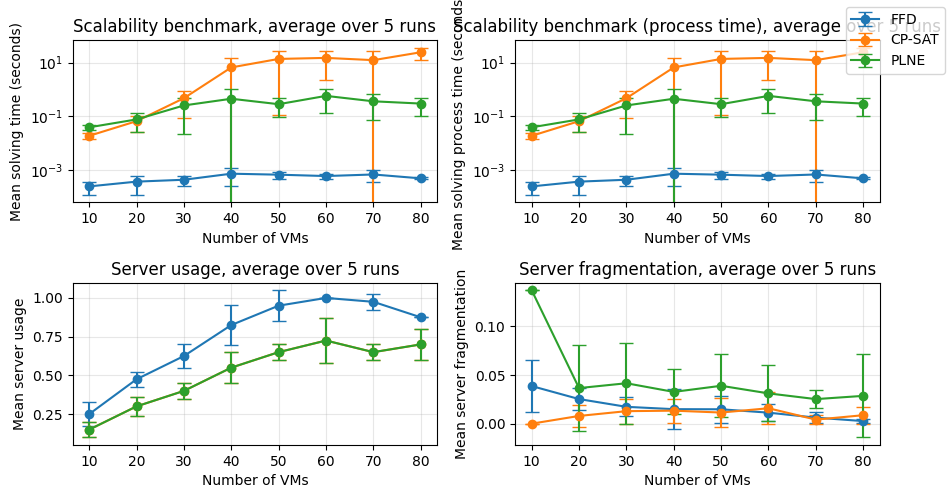

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5))

time_ax = axes[0, 0]
process_time_ax = axes[0, 1]
server_usage_ax = axes[1, 0]
fragmentation_ax = axes[1, 1]

for solver_name in SOLVER_FACTORIES:
    time_ax.errorbar(
        benchmark_summary.index.get_level_values("requested_vms").unique(),
        benchmark_summary.xs(solver_name, level="solver")["avg_time"],
        yerr=benchmark_summary.xs(solver_name, level="solver")["std_time"],
        marker="o",
        capsize=5,
        label=solver_name,
    )
    process_time_ax.errorbar(
        benchmark_summary.index.get_level_values("requested_vms").unique(),
        benchmark_summary.xs(solver_name, level="solver")["avg_process_time"],
        yerr=benchmark_summary.xs(solver_name, level="solver")[
            "std_process_time"
        ],
        marker="o",
        capsize=5,
    )
    server_usage_ax.errorbar(
        benchmark_summary.index.get_level_values("requested_vms").unique(),
        benchmark_summary.xs(solver_name, level="solver")["avg_server_usage"],
        yerr=benchmark_summary.xs(solver_name, level="solver")[
            "std_server_usage"
        ],
        marker="o",
        capsize=5,
    )
    fragmentation_ax.errorbar(
        benchmark_summary.index.get_level_values("requested_vms").unique(),
        benchmark_summary.xs(solver_name, level="solver")["avg_fragmentation"],
        yerr=benchmark_summary.xs(solver_name, level="solver")[
            "std_fragmentation"
        ],
        marker="o",
        capsize=5,
    )

time_ax.set_title(f"Scalability benchmark, average over {N_RUNS} runs")
time_ax.set_xlabel("Number of VMs")
time_ax.set_yscale("log")
time_ax.set_ylabel("Mean solving time (seconds)")
time_ax.grid(True, alpha=0.3)

process_time_ax.set_title(
    f"Scalability benchmark (process time), average over {N_RUNS} runs"
)
process_time_ax.set_xlabel("Number of VMs")
process_time_ax.set_yscale("log")
process_time_ax.set_ylabel("Mean solving process time (seconds)")
process_time_ax.grid(True, alpha=0.3)

server_usage_ax.set_title(f"Server usage, average over {N_RUNS} runs")
server_usage_ax.set_xlabel("Number of VMs")
server_usage_ax.set_ylabel("Mean server usage")
server_usage_ax.grid(True, alpha=0.3)

fragmentation_ax.set_title(f"Server fragmentation, average over {N_RUNS} runs")
fragmentation_ax.set_xlabel("Number of VMs")
fragmentation_ax.set_ylabel("Mean server fragmentation")
fragmentation_ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles, labels)
plt.tight_layout()
plt.show()

# INTERPRETATION OF THE RESULTS

First Fit Decreasing (FFD), Mixed Integer Linear Programming (MILP/PLNE), and CP-SAT solvers exhibit very different performance characteristics in virtual machine allocation problems. FFD is a heuristic approach designed for speed and scalability; it produces solutions almost instantly even for large datasets, but the solutions are not always optimal and may lead to higher resource fragmentation. In contrast, MILP solvers aim to find mathematically optimal solutions by exploring a large combinatorial search space, which often results in significantly higher computation times as the problem size and number of constraints increase. CP-SAT represents a modern compromise between these two approaches: it combines constraint programming, SAT solving, and optimization techniques to achieve near-optimal or optimal solutions while remaining substantially faster and more scalable than traditional MILP formulations. In practice, FFD is usually the fastest method, MILP the slowest but most exact, and CP-SAT offers the best balance between execution time and solution quality for complex VM allocation scenarios involving affinity, anti-affinity, and capacity constraints.

# FRAGMENTATION BENCHMARCK

In [25]:
print(
    "Fragmentation percentage and number of servers used for each algorithm: (lower is better)\n\n"
)

if solution_context_fdd is None:
    print("FFD didn't find any solution")
else:
    (fragmentation, server_used) = (
        solution_context_fdd.fragmentation(),
        solution_context_fdd.server_usage(),
    )
    fragmentation = round(fragmentation, 2)
    server_used = round(server_used, 2)
    print(f"Fragmentation percentage for FDD: {fragmentation}%")
    print(f"Number of servers used for FDD: {server_used}%\n")

if solution_context_plne is None:
    print("PLNE didn't find any solution")
else:
    (fragmentation, server_used) = (
        solution_context_plne.fragmentation(),
        solution_context_plne.server_usage(),
    )
    fragmentation = round(fragmentation, 2)
    server_used = round(server_used, 2)
    print(f"Fragmentation percentage for PLNE: {fragmentation}%")
    print(f"Number of servers used for PLNE: {server_used}%\n")

if solution_context_cpsat is None:
    print("CP-SAT didn't find any solution")
else:
    (fragmentation, server_used) = (
        solution_context_cpsat.fragmentation(),
        solution_context_cpsat.server_usage(),
    )
    fragmentation = round(fragmentation, 2)
    server_used = round(server_used, 2)
    print(f"Fragmentation percentage for CPSAT: {fragmentation}%")
    print(f"Number of servers used for CPSAT: {server_used}%")

Fragmentation percentage and number of servers used for each algorithm: (lower is better)


Fragmentation percentage for FDD: 0.02%
Number of servers used for FDD: 0.87%

Fragmentation percentage for PLNE: 0.01%
Number of servers used for PLNE: 0.67%

Fragmentation percentage for CPSAT: 0.0%
Number of servers used for CPSAT: 0.67%


# CONCLUSION

The results show that both PLNE and CPSAT perform better than the FDD heuristic in terms of resource allocation quality. FDD produces a more scattered allocation and uses a larger number of servers, which indicates less efficient consolidation of virtual machines. In contrast, PLNE and CPSAT achieve a more balanced allocation with fewer active servers, meaning they manage to pack virtual machines more efficiently and make better use of the available resources. Overall, the optimization-based approaches provide more effective and compact solutions compared to the greedy heuristic.


The results highlight a clear trade-off between speed and solution quality among the three approaches. The FDD heuristic is extremely fast, making it suitable for real-time or large-scale scenarios where quick decisions are needed, but this comes at the cost of less efficient resource allocation. In contrast, PLNE and CPSAT require significantly more computation time due to their optimization-based nature, but they produce higher-quality solutions with better resource utilization and lower fragmentation. Overall, heuristic methods favor speed, while exact or constraint-based solvers favor solution quality.
